<a href="https://colab.research.google.com/github/jaychang0405/pitch-prediction-xgboost-2026/blob/main/2026_pitch_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- 1. 環境設定與套件安裝 ---
套件安裝與匯入完成。

--- 2. 資料下載 ---
正在下載 2023 賽季全聯盟 Statcast 資料 (2023-04-01 到 2023-10-01)...
This is a large query, it may take a moment to complete


100%|██████████| 184/184 [00:11<00:00, 16.13it/s]


成功下載 2023 賽季 714,703 筆資料。

已成功合併數據，總共 714,703 筆全聯盟資料。
剃除無效空值後，剩餘 711,720 筆有效資料。

--- 3. 開始進行特徵工程 ---
進行特徵編碼...
預測目標: ['Changeup' 'Curveball' 'Fastball_System' 'Slider_Cutter']
特徵工程完成！X_train shape: (567110, 36)

--- 4. 模型訓練 (全聯盟自動平衡) ---
開始訓練 XGBoost (這會花一點時間)...
訓練完成！

 🏆 全聯盟預測評估結果 (海報專用指標)
 整體準確率 (Accuracy): 37.03%
 Macro F1-Score:      0.3516
 Brier Score:         0.7006 (越低越好)

 模型進步對比 (Model vs Baseline)
 盲猜基準線 Accuracy: 47.80%
 盲猜基準線 Macro F1: 0.1617
 本模型 Macro F1:  0.3516 (提升: +117.4% )

[詳細分類報告]
                 precision    recall  f1-score   support

       Changeup       0.25      0.51      0.34     18599
      Curveball       0.18      0.44      0.26     12330
Fastball_System       0.66      0.24      0.36     67774
  Slider_Cutter       0.43      0.49      0.46     43075

       accuracy                           0.37    141778
      macro avg       0.38      0.42      0.35    141778
   weighted avg       0.49      0.37      0.38    141778


★ Top-2 準確率 (前兩名包含真實球種): 67.91%

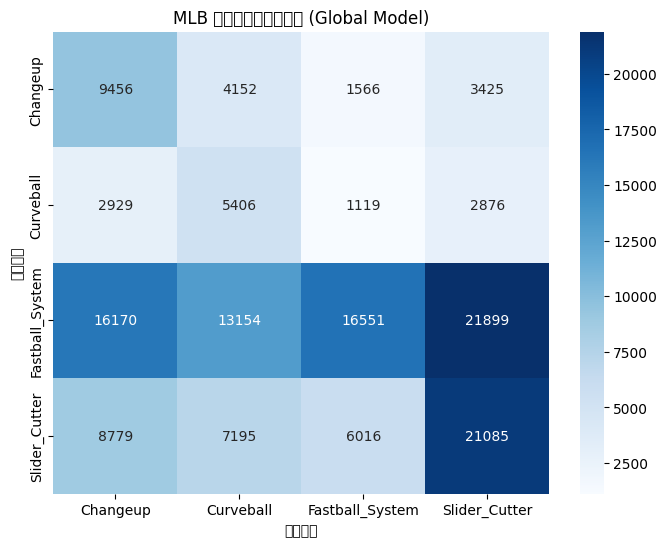

In [ ]:
# ================================================================
# [區塊 1] 環境設定與資料下載 (全聯盟通用版)
# 功能：抓取全聯盟大數據、不限單一投手
# ================================================================

print("--- 1. 環境設定與套件安裝 ---")
!pip install -q pybaseball xgboost scikit-learn matplotlib seaborn tqdm

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pybaseball import statcast
import pybaseball as pyb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.dummy import DummyClassifier
import xgboost as xgb
import warnings

warnings.filterwarnings('ignore')
pyb.cache.enable()
print("套件安裝與匯入完成。")

print("\n--- 2. 資料下載 ---")
# ⚠️ 注意：全聯盟三年資料破200萬筆，為避免Colab記憶體崩潰，先以 2023 年示範。
# 若資源允許，可改回 YEARS = [2021, 2022, 2023]
YEARS = [2023]

all_data = []
for year in YEARS:
    start_dt = f'{year}-04-01'
    end_dt = f'{year}-10-01'
    print(f"正在下載 {year} 賽季全聯盟 Statcast 資料 ({start_dt} 到 {end_dt})...")
    try:
        data = statcast(start_dt=start_dt, end_dt=end_dt)
        if data is not None and not data.empty:
            print(f"成功下載 {year} 賽季 {len(data):,} 筆資料。")
            all_data.append(data)
    except Exception as e:
        print(f"下載 {year} 時發生錯誤: {e}")

if not all_data:
    raise ValueError("資料下載失敗！")

raw_data = pd.concat(all_data, ignore_index=True)
print(f"\n已成功合併數據，總共 {len(raw_data):,} 筆全聯盟資料。")

# 基本清理：剃除沒有球種紀錄的無效球
df_all = raw_data.dropna(subset=['pitch_type', 'pitcher', 'batter']).copy()
print(f"剃除無效空值後，剩餘 {len(df_all):,} 筆有效資料。")


# ================================================================
# [區塊 2] 特徵工程 (全聯盟通用版)
# ================================================================
print("\n--- 3. 開始進行特徵工程 ---")
df = df_all.copy()

# 1. 基礎清理與新增特徵
cols_to_fill_0 = ['balls', 'strikes', 'outs_when_up', 'inning']
df[cols_to_fill_0] = df[cols_to_fill_0].fillna(0)
for base in ['on_1b', 'on_2b', 'on_3b']:
    df[base] = df[base].apply(lambda x: 1 if pd.notna(x) else 0)

df['pitch_number'] = df['pitch_number'].fillna(1).astype(float)
df['score_diff'] = df['fld_score'] - df['bat_score']
df['count'] = df['balls'].astype(int).astype(str) + '-' + df['strikes'].astype(int).astype(str)

# 處理左右打與「左右投」 (全聯盟模型必備)
df['stand'] = df['stand'].fillna('Unknown')
df['p_throws'] = df['p_throws'].fillna('Unknown') # 新增：投手慣用手

# 2. 球種合併
def group_pitches(pitch):
    if pitch in ['FF', 'SI']: return 'Fastball_System'
    elif pitch in ['SL', 'FC', 'ST', 'SV']: return 'Slider_Cutter'
    elif pitch in ['KC', 'CU']: return 'Curveball'
    elif pitch in ['CH', 'FS']: return 'Changeup'
    else: return 'Other'

df['grouped_pitch'] = df['pitch_type'].apply(group_pitches)
df = df[df['grouped_pitch'] != 'Other'].copy()

# 3. 準備上一球結果
key_outcomes = ['swinging_strike', 'foul', 'ball', 'called_strike', 'hit_into_play']
df['pitch_outcome'] = df['description'].apply(lambda x: x if x in key_outcomes else 'other')

# -------------------------------------------------------------------
# 4. 時間排序與序列特徵 (嚴格防漏)
# -------------------------------------------------------------------
# 新增 pitcher 到排序和 groupby 中，確保上一球真的是「同一個投手」投的
df = df.sort_values(by=['game_pk', 'inning', 'pitcher', 'at_bat_number', 'pitch_number'])
df = df.reset_index(drop=True)

g = df.groupby(['game_pk', 'pitcher', 'at_bat_number'])

df['prev_grouped_pitch'] = g['grouped_pitch'].shift(1).fillna('First_Pitch')
df['prev_pitch_outcome'] = g['pitch_outcome'].shift(1).fillna('First_Pitch')
df['prev_plate_x'] = g['plate_x'].shift(1).fillna(0)
df['prev_plate_z'] = g['plate_z'].shift(1).fillna(2.5)

# -------------------------------------------------------------------
# 5. One-Hot Encoding 與 數值化
# -------------------------------------------------------------------
print("進行特徵編碼...")
# 加入 p_throws 作為類別特徵
cols_to_encode = ['count', 'stand', 'p_throws', 'prev_grouped_pitch', 'prev_pitch_outcome']

cols_numeric = [
    'outs_when_up', 'inning', 'score_diff', 'pitch_number',
    'on_1b', 'on_2b', 'on_3b',
    'prev_plate_x', 'prev_plate_z'
]

df_model = pd.get_dummies(df, columns=cols_to_encode, prefix=cols_to_encode, dtype=int)

feature_cols = cols_numeric + [c for c in df_model.columns if any(c.startswith(p) for p in cols_to_encode)]
X_df = df_model[feature_cols]

# 目標編碼
le_pitch = LabelEncoder()
y_encoded = le_pitch.fit_transform(df['grouped_pitch'])
pitch_classes = le_pitch.classes_
print(f"預測目標: {pitch_classes}")

# -------------------------------------------------------------------
# 6. 切割資料集 (改為隨機切割，因為只有一年資料)
# -------------------------------------------------------------------
X_numpy = X_df.to_numpy(dtype='float32')
y_numpy = y_encoded

# 留 20% 當測試集
X_train, X_test, y_train, y_test = train_test_split(X_numpy, y_numpy, test_size=0.2, random_state=42, stratify=y_numpy)

feature_names = X_df.columns.tolist()
print(f"特徵工程完成！X_train shape: {X_train.shape}")


# ================================================================
# [區塊 3] 模型訓練 (自動平衡版)
# ================================================================
print("\n--- 4. 模型訓練 (全聯盟自動平衡) ---")

# 使用 sklearn 自動計算全聯盟的權重，取代以前的手動設定
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

# 建立 XGBoost (稍微加深 max_depth 因為資料變多了)
xgb_clf = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=len(pitch_classes),
    n_estimators=300,
    max_depth=6,        # 全聯盟特徵較複雜，深度從4提升到6
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric='mlogloss'
)

print("開始訓練 XGBoost (這會花一點時間)...")
xgb_clf.fit(X_train, y_train, sample_weight=sample_weights, verbose=False)
print("訓練完成！")

# ================================================================
# [評估] (新增 Baseline 比較與海報指標)
# ================================================================

# 取得預測機率與預測類別
y_pred_prob = xgb_clf.predict_proba(X_test)
y_pred_class = xgb_clf.predict(X_test)

# 將編碼轉回文字名稱
y_test_names = le_pitch.inverse_transform(y_test)
y_pred_names = le_pitch.inverse_transform(y_pred_class)

# --- 1. 計算你的模型數據 ---
acc = accuracy_score(y_test, y_pred_class)
macro_f1 = f1_score(y_test, y_pred_class, average='macro')

# Brier Score 公式：計算每個樣本預測機率與真實結果的平方差，並取平均
y_test_one_hot = pd.get_dummies(y_test).to_numpy()
brier_score = np.mean(np.sum((y_pred_prob - y_test_one_hot)**2, axis=1))

print("\n" + "="*50)
print(f" 🏆 全聯盟預測評估結果 (海報專用指標)")
print(f" 整體準確率 (Accuracy): {acc:.2%}")
print(f" Macro F1-Score:      {macro_f1:.4f}")
print(f" Brier Score:         {brier_score:.4f} (越低越好)")
print("="*50)

# --- 2. ★ 新增：計算盲猜基準線 (Baseline) ---
# 建立一個「永遠只猜多數決 (直球)」的假模型
dummy_clf = DummyClassifier(strategy="most_frequent")
dummy_clf.fit(X_train, y_train)
y_dummy_pred = dummy_clf.predict(X_test)

dummy_acc = accuracy_score(y_test, y_dummy_pred)
dummy_macro_f1 = f1_score(y_test, y_dummy_pred, average='macro')

print("\n" + "="*50)
print(f" 模型進步對比 (Model vs Baseline)")
print(f" 盲猜基準線 Accuracy: {dummy_acc:.2%}")
print(f" 盲猜基準線 Macro F1: {dummy_macro_f1:.4f}")
print(f" 本模型 Macro F1:  {macro_f1:.4f} (提升: +{(macro_f1 - dummy_macro_f1) / dummy_macro_f1:.1%} )")
print("="*50)

# --- 3. 印出詳細分類報告 ---
print("\n[詳細分類報告]")
print(classification_report(y_test_names, y_pred_names, target_names=pitch_classes))

# --- 4. 計算 Top-2 準確率 ---
probs_sorted = np.argsort(-y_pred_prob, axis=1)
top1_indices = probs_sorted[:, 0]
top2_indices = probs_sorted[:, 1]
top1_names = le_pitch.inverse_transform(top1_indices)
top2_names = le_pitch.inverse_transform(top2_indices)

hit_top2 = [(true_name == t1) or (true_name == t2) for true_name, t1, t2 in zip(y_test_names, top1_names, top2_names)]
top2_acc = np.mean(hit_top2)

print(f"\n★ Top-2 準確率 (前兩名包含真實球種): {top2_acc:.2%}")

# --- 5. 畫出混淆矩陣 ---
cm = confusion_matrix(y_test_names, y_pred_names, labels=pitch_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=pitch_classes, yticklabels=pitch_classes)
plt.ylabel('真實類別')
plt.xlabel('預測類別')
plt.title('MLB 全聯盟配球預測模型 (Global Model)')
plt.show()

# 最後把模型跟 LabelEncoder 存起來，寒假做網頁時直接載入！
# import joblib
# joblib.dump(xgb_clf, 'mlb_pitch_model.pkl')
# joblib.dump(le_pitch, 'mlb_label_encoder.pkl')
# joblib.dump(feature_names, 'mlb_feature_names.pkl')
# print("模型儲存成功！網頁開發準備就緒。")

In [ ]:
import pandas as pd
from pybaseball import chadwick_register

print("--- 開始產生球員字典檔 ---")
print("1. 正在下載 MLB 官方球員註冊表 (Chadwick Register)...")
# 取得大聯盟所有球員的名冊
chadwick_df = chadwick_register()

# 將名字組合起來 (FirstName LastName)
chadwick_df['player_name'] = chadwick_df['name_first'] + " " + chadwick_df['name_last']

# 只保留我們需要的欄位 (MLB ID 對應的欄位是 key_mlbam)
player_dict = chadwick_df[['key_mlbam', 'player_name']].dropna()

print("2. 正在與你下載的 raw_data 進行比對...")
# 取得 raw_data 中實際有投球/打擊的獨一無二 ID
unique_pitchers = raw_data['pitcher'].dropna().unique()
unique_batters = raw_data['batter'].dropna().unique()

# 轉換成 DataFrame 並與大字典進行合併 (Merge)
df_pitchers = pd.DataFrame({'pitcher': unique_pitchers})
df_pitchers = df_pitchers.merge(player_dict, left_on='pitcher', right_on='key_mlbam', how='inner')
df_pitchers = df_pitchers[['pitcher', 'player_name']] # 最終只留兩欄

df_batters = pd.DataFrame({'batter': unique_batters})
df_batters = df_batters.merge(player_dict, left_on='batter', right_on='key_mlbam', how='inner')
df_batters = df_batters[['batter', 'player_name']] # 最終只留兩欄

print("3. 正在匯出 CSV 檔案...")
# 輸出為 CSV (取消 index 以免多一個沒用的欄位)
df_pitchers.to_csv('pitcher_dict.csv', index=False)
df_batters.to_csv('batter_dict.csv', index=False)

print("\n✅ 完成！產出結果：")
print(f" - 投手字典: 包含 {len(df_pitchers)} 位投手 (pitcher_dict.csv)")
print(f" - 打者字典: 包含 {len(df_batters)} 位打者 (batter_dict.csv)")

--- 開始產生球員字典檔 ---
1. 正在下載 MLB 官方球員註冊表 (Chadwick Register)...
Gathering player lookup table. This may take a moment.
2. 正在與你下載的 raw_data 進行比對...
3. 正在匯出 CSV 檔案...

✅ 完成！產出結果：
 - 投手字典: 包含 862 位投手 (pitcher_dict.csv)
 - 打者字典: 包含 656 位打者 (batter_dict.csv)
